In [ ]:
import pandas as pd
from CCA_utils import *

In [ ]:
study_sovereigns = [
    'Saudi Arabia', 'Abu Dhabi', 'Dubai', 'Qatar', 'Colombia',
    'Mexico', 'Brazil', 'Egypt', 'Malaysia','Indonesia', 'Philippines', 'Turkey', 'Chile', 'China',
    'South Africa', 'South Korea', 'Thailand']

cca_panel_df = pd.read_csv('cca_panel_newdebt.csv')
cca_panel_df['date'] = pd.to_datetime(cca_panel_df['date'])
cca_panel_df = cca_panel_df[cca_panel_df['country'].isin(study_sovereigns)].copy()


ovx_df = pd.read_csv('../data/processed/Macroeconomic_variables/OVXCLS.csv')
ovx_df['date'] = pd.to_datetime(ovx_df['date'])

cca_panel_df = cca_panel_df.merge(ovx_df[['date','OVXCLS']], on='date', how='left')



cca_panel_df.drop(columns=['cds_spread_1Y'], inplace=True)
cca_panel_df.rename(columns={'cds_spread_5Y': 'cds_spread'}, inplace=True)


T=1.0
vol_window = 52
freq = 'W'
k=1.64
n_paths=1
seed = 42
ovxqtl = 0.85



#This replace with msci corr with oil returns.
RHO_DEFAULT = 0.25

MSCI_EM_constituent_list = [ "Brazil", "Chile", "China", "Colombia", "Czechia", "Egypt",
                             "Greece", "Hungary", "India", "Indonesia", "South Korea", "Kuwait", 
                             "Malaysia", "Mexico", "Peru", "Philippines", "Poland", "Qatar",
                            "Saudi Arabia", "South Africa", "Taiwan", "Thailand", "Turkey", "United Arab Emirates"]


THETA_MAP = {
    "Brazil":0.2, "Chile":0, "China":0, "Colombia":0.1, "Czechia":0, 
    "Egypt":0.2, "Greece":0, "Hungary":0, "India":0, "Indonesia":0,
    "South Korea":0.1, "Kuwait":0.1, "Malaysia":0.1, "Mexico":0.1, 
    "Peru":0, "Philippines":0, "Poland":0, "Qatar":0.5,
    "Saudi Arabia":0.5, "South Africa":0, "Taiwan":0, 
    "Thailand":0, "Turkey":0, "Dubai":0.5, "Abu Dhabi":0.5}


In [ ]:
pricer = JumpDiffusionPricer(steps=52, n_paths=5000)

results = pd.DataFrame()
for country, group in cca_panel_df.groupby('country'):
    df = group.copy().sort_values('date').reset_index(drop=True)

    r_d = df['domestic_rate_in_units'] / 100
    r_f = df['risk_free_rate'] / 100
    M_bn = df['monetary_base_mn_localcurr'] / 1000
    dom_D_bn = df['domestic_debt_bn_localcurr']
    ext_D_bn = df['external_debt_mn_usd'] / 1000
    fx_rate = df['fx_rate']

    # --- LCL$ ---
    df['LCL_usd'] = [
        compute_lcl_usd(m, bd, fx, rd, rf, T)
        for m, bd, fx, rd, rf in zip(
            M_bn, dom_D_bn, fx_rate, r_d, r_f
        )
    ]

    ann_factor = np.sqrt(52) if freq == 'W' else np.sqrt(12)
    log_ret = np.log(df['LCL_usd'] / df['LCL_usd'].shift(1))
    df['sigma_lcl'] = log_ret.rolling(window=vol_window).std() * ann_factor
    
    # --- Barrier ---
    df['B_f'] = [
            compute_barrier_kvm(debt, rf, T)
            for debt, rf in zip(
                ext_D_bn, r_f
            )
        ]

    df['lamovx'] = np.where(
        df['OVXCLS'] < 30, 0, np.where(df['OVXCLS']<50,0.25,
        np.where(df['OVXCLS']<70, 0.5,1)))
    
        
    # --- Solve CCA for each week ---
    out = {'implied_V': [], 'implied_sigma_V': [], 'cca_converged': [],
           'distance_to_distress': [], 'default_prob': [],
           'model_spread_bps': [], 'put_value': [], 'risky_debt': [],
           'leverage': []}
    
    for i, row in df.iterrows():

        lam_i = row['lamovx']
        eta = 20

        cca_base = solve_CCA(row['LCL_usd'], row['sigma_lcl'], row['B_f'],
                                r_f.iloc[i], T)
        
        if lam_i==0:
            risk = compute_risk(cca_base['V'], cca_base['sigma_V'], row['B_f'],
                            r_f.iloc[i], T)
        else:   
            risk = pricer.compute_risk_jd(cca_base['V'], cca_base['sigma_V'], row['B_f'],
                                       r_f.iloc[i], T, lam=lam_i, eta=eta, seed=42)
                # store baseline results...
        out['implied_V'].append(cca_base['V'])
        out['implied_sigma_V'].append(cca_base['sigma_V'])
        out['cca_converged'].append(cca_base['converged'])
        out['distance_to_distress'].append(risk['d2'])
        out['default_prob'].append(risk['default_prob'])
        out['model_spread_bps'].append(risk['credit_spread_bps'])
        out['put_value'].append(risk['put_value'])
        out['risky_debt'].append(risk['risky_debt'])
        out['leverage'].append(risk['leverage'])

    for col, vals in out.items():
        df[col] = vals

    results = pd.concat([results, df])
    print(f"  {country:5s} ")

  Abu Dhabi 
  Brazil 
  Chile 
  China 
  Colombia 
  Dubai 
  Egypt 
  Indonesia 
  Malaysia 
  Mexico 
  Philippines 
  Qatar 
  Saudi Arabia 
  South Africa 
  South Korea 
  Thailand 
  Turkey 


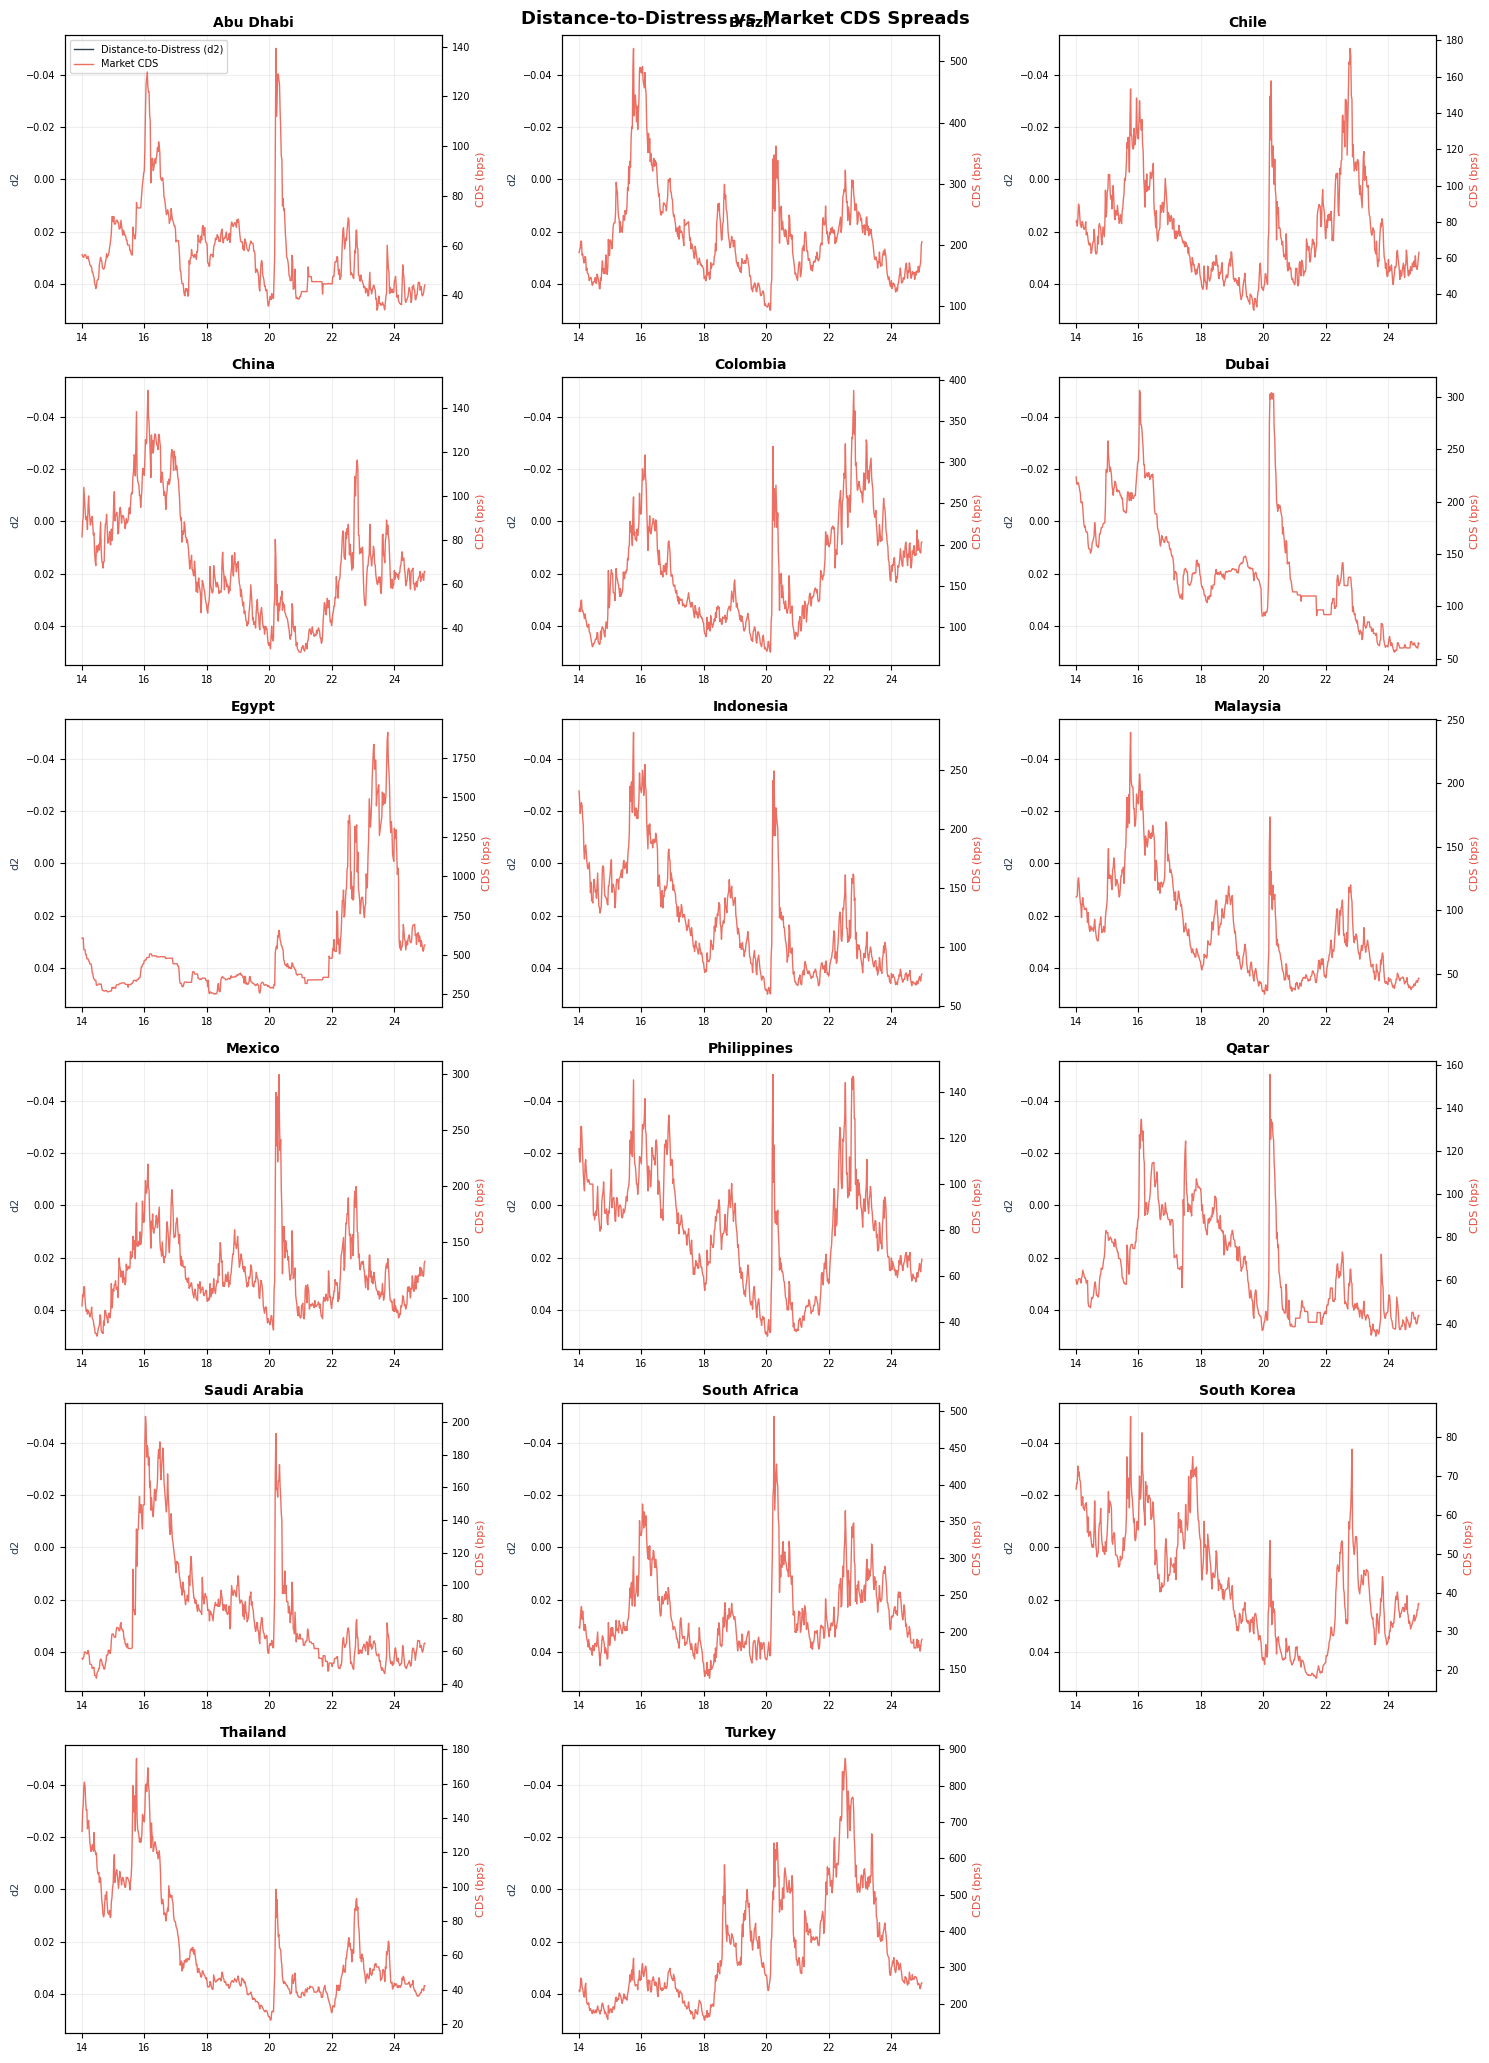

In [36]:
d2_vs_cds = plot_d2_vs_cds(results)

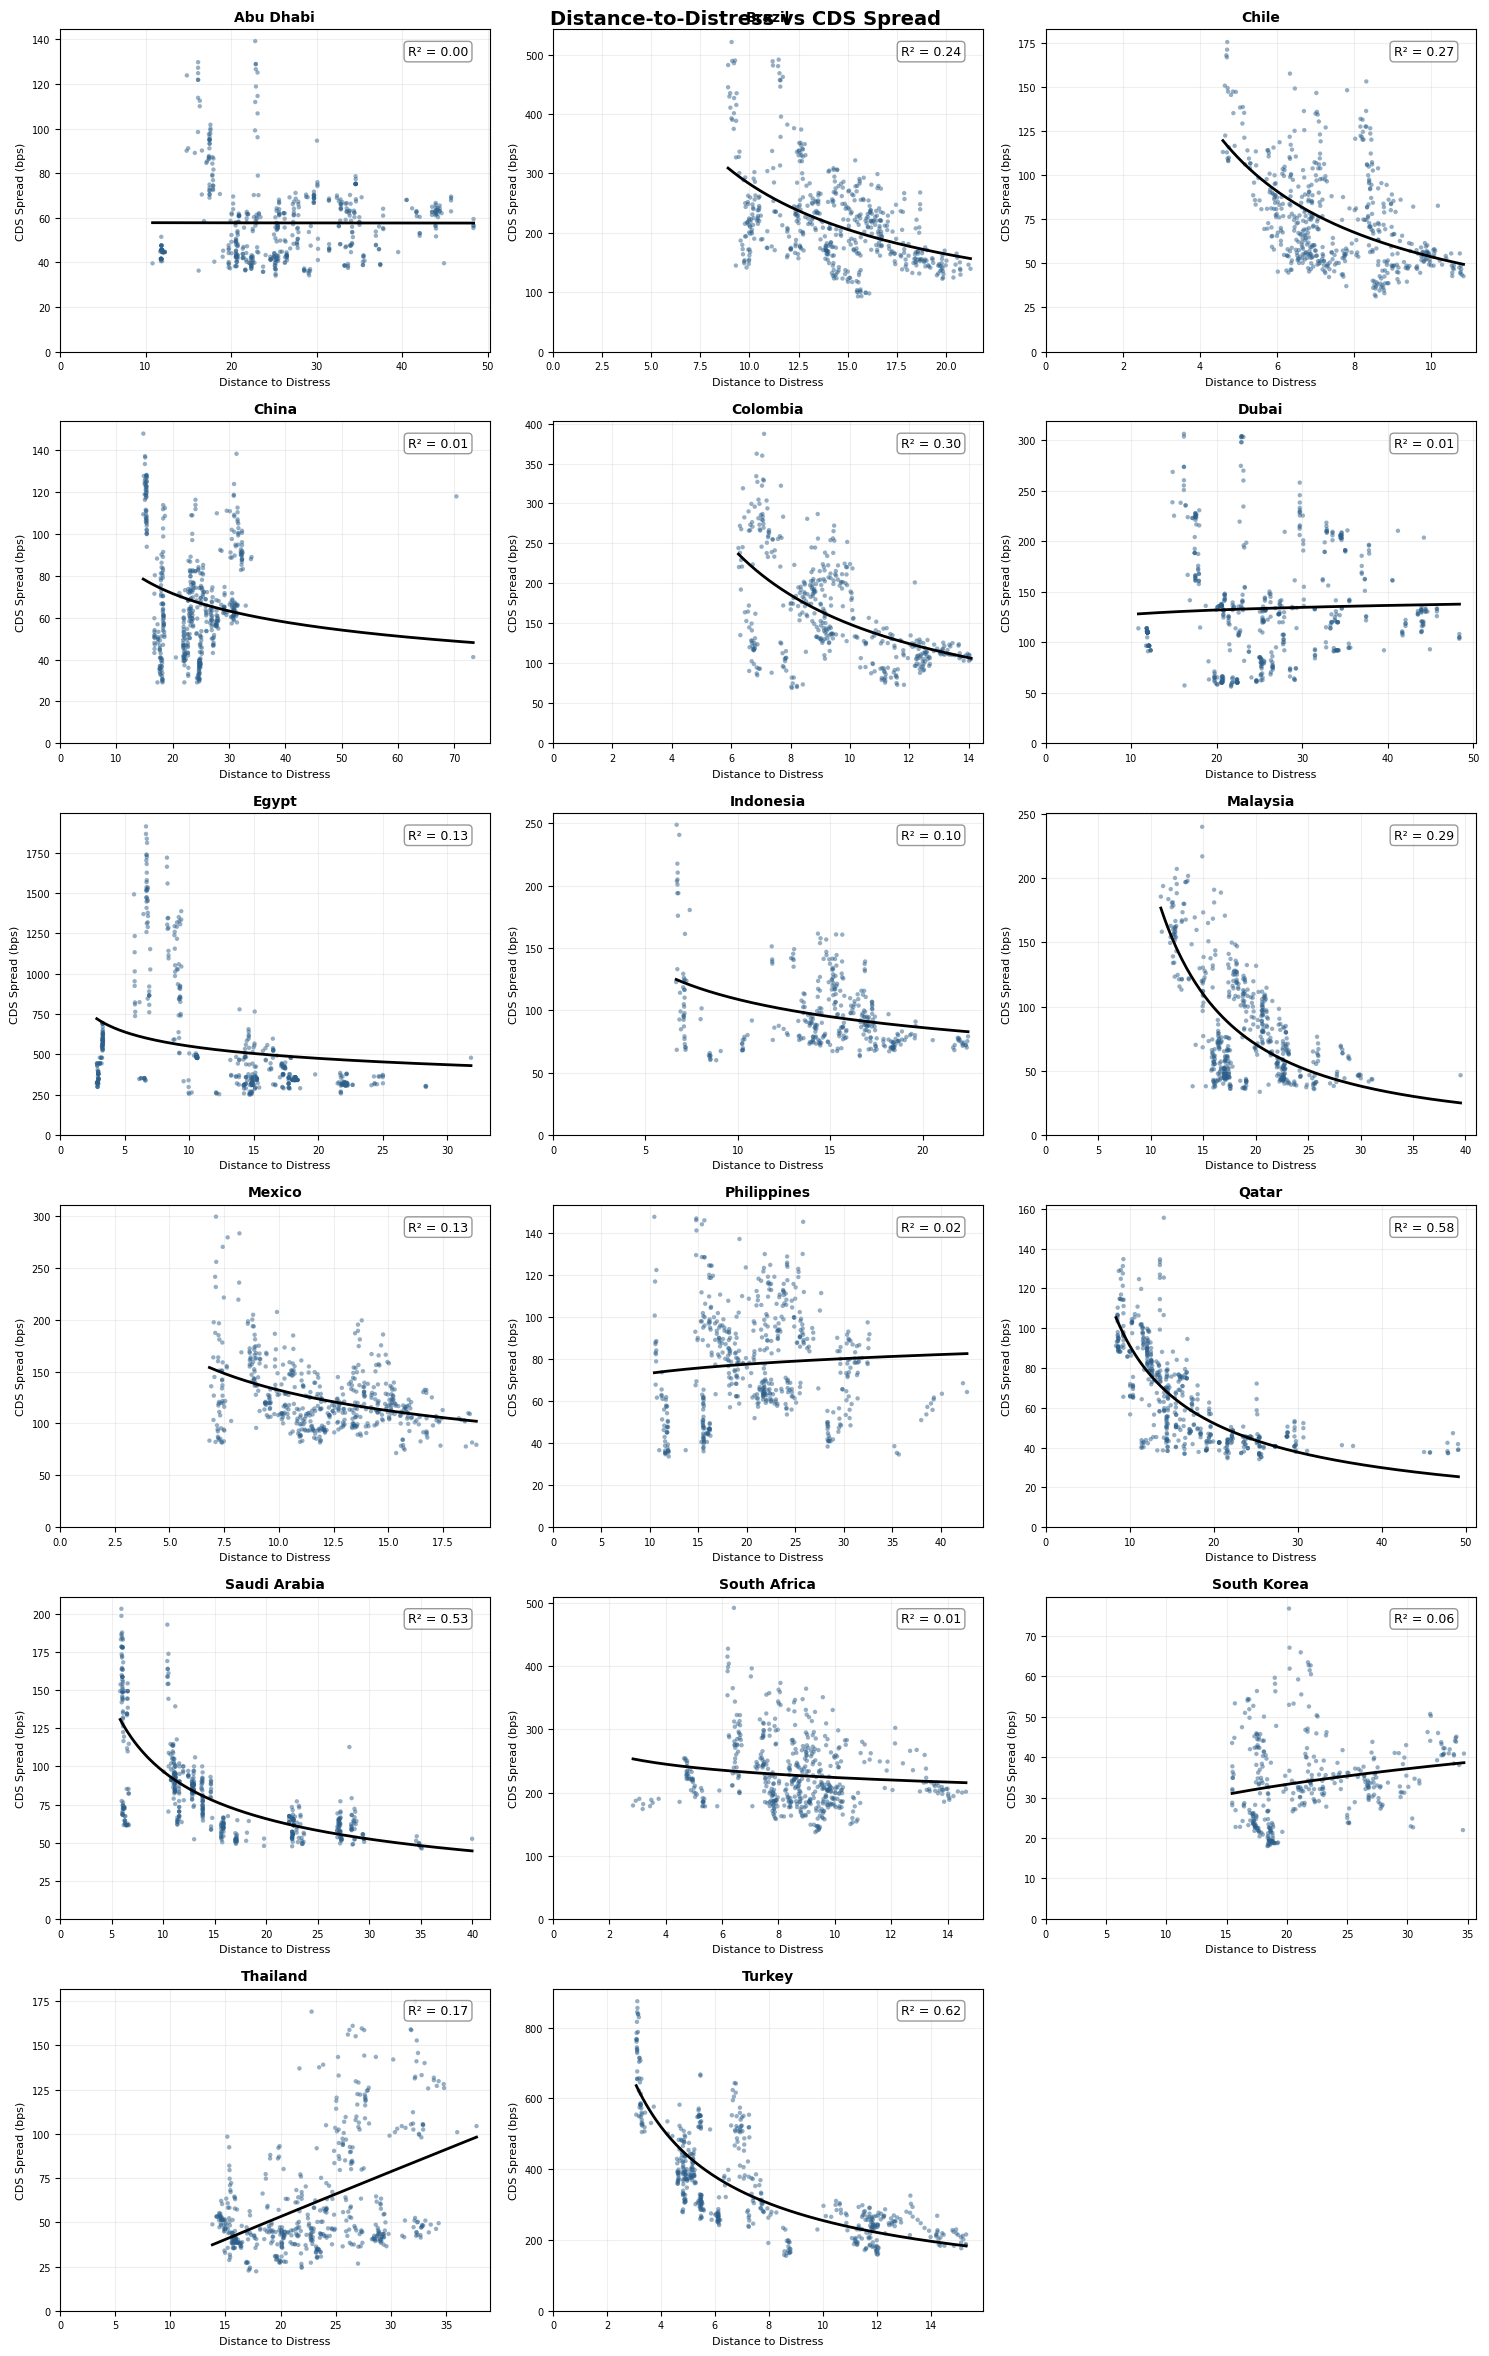

In [33]:
d2_scatter = plot_d2_scatter(results)

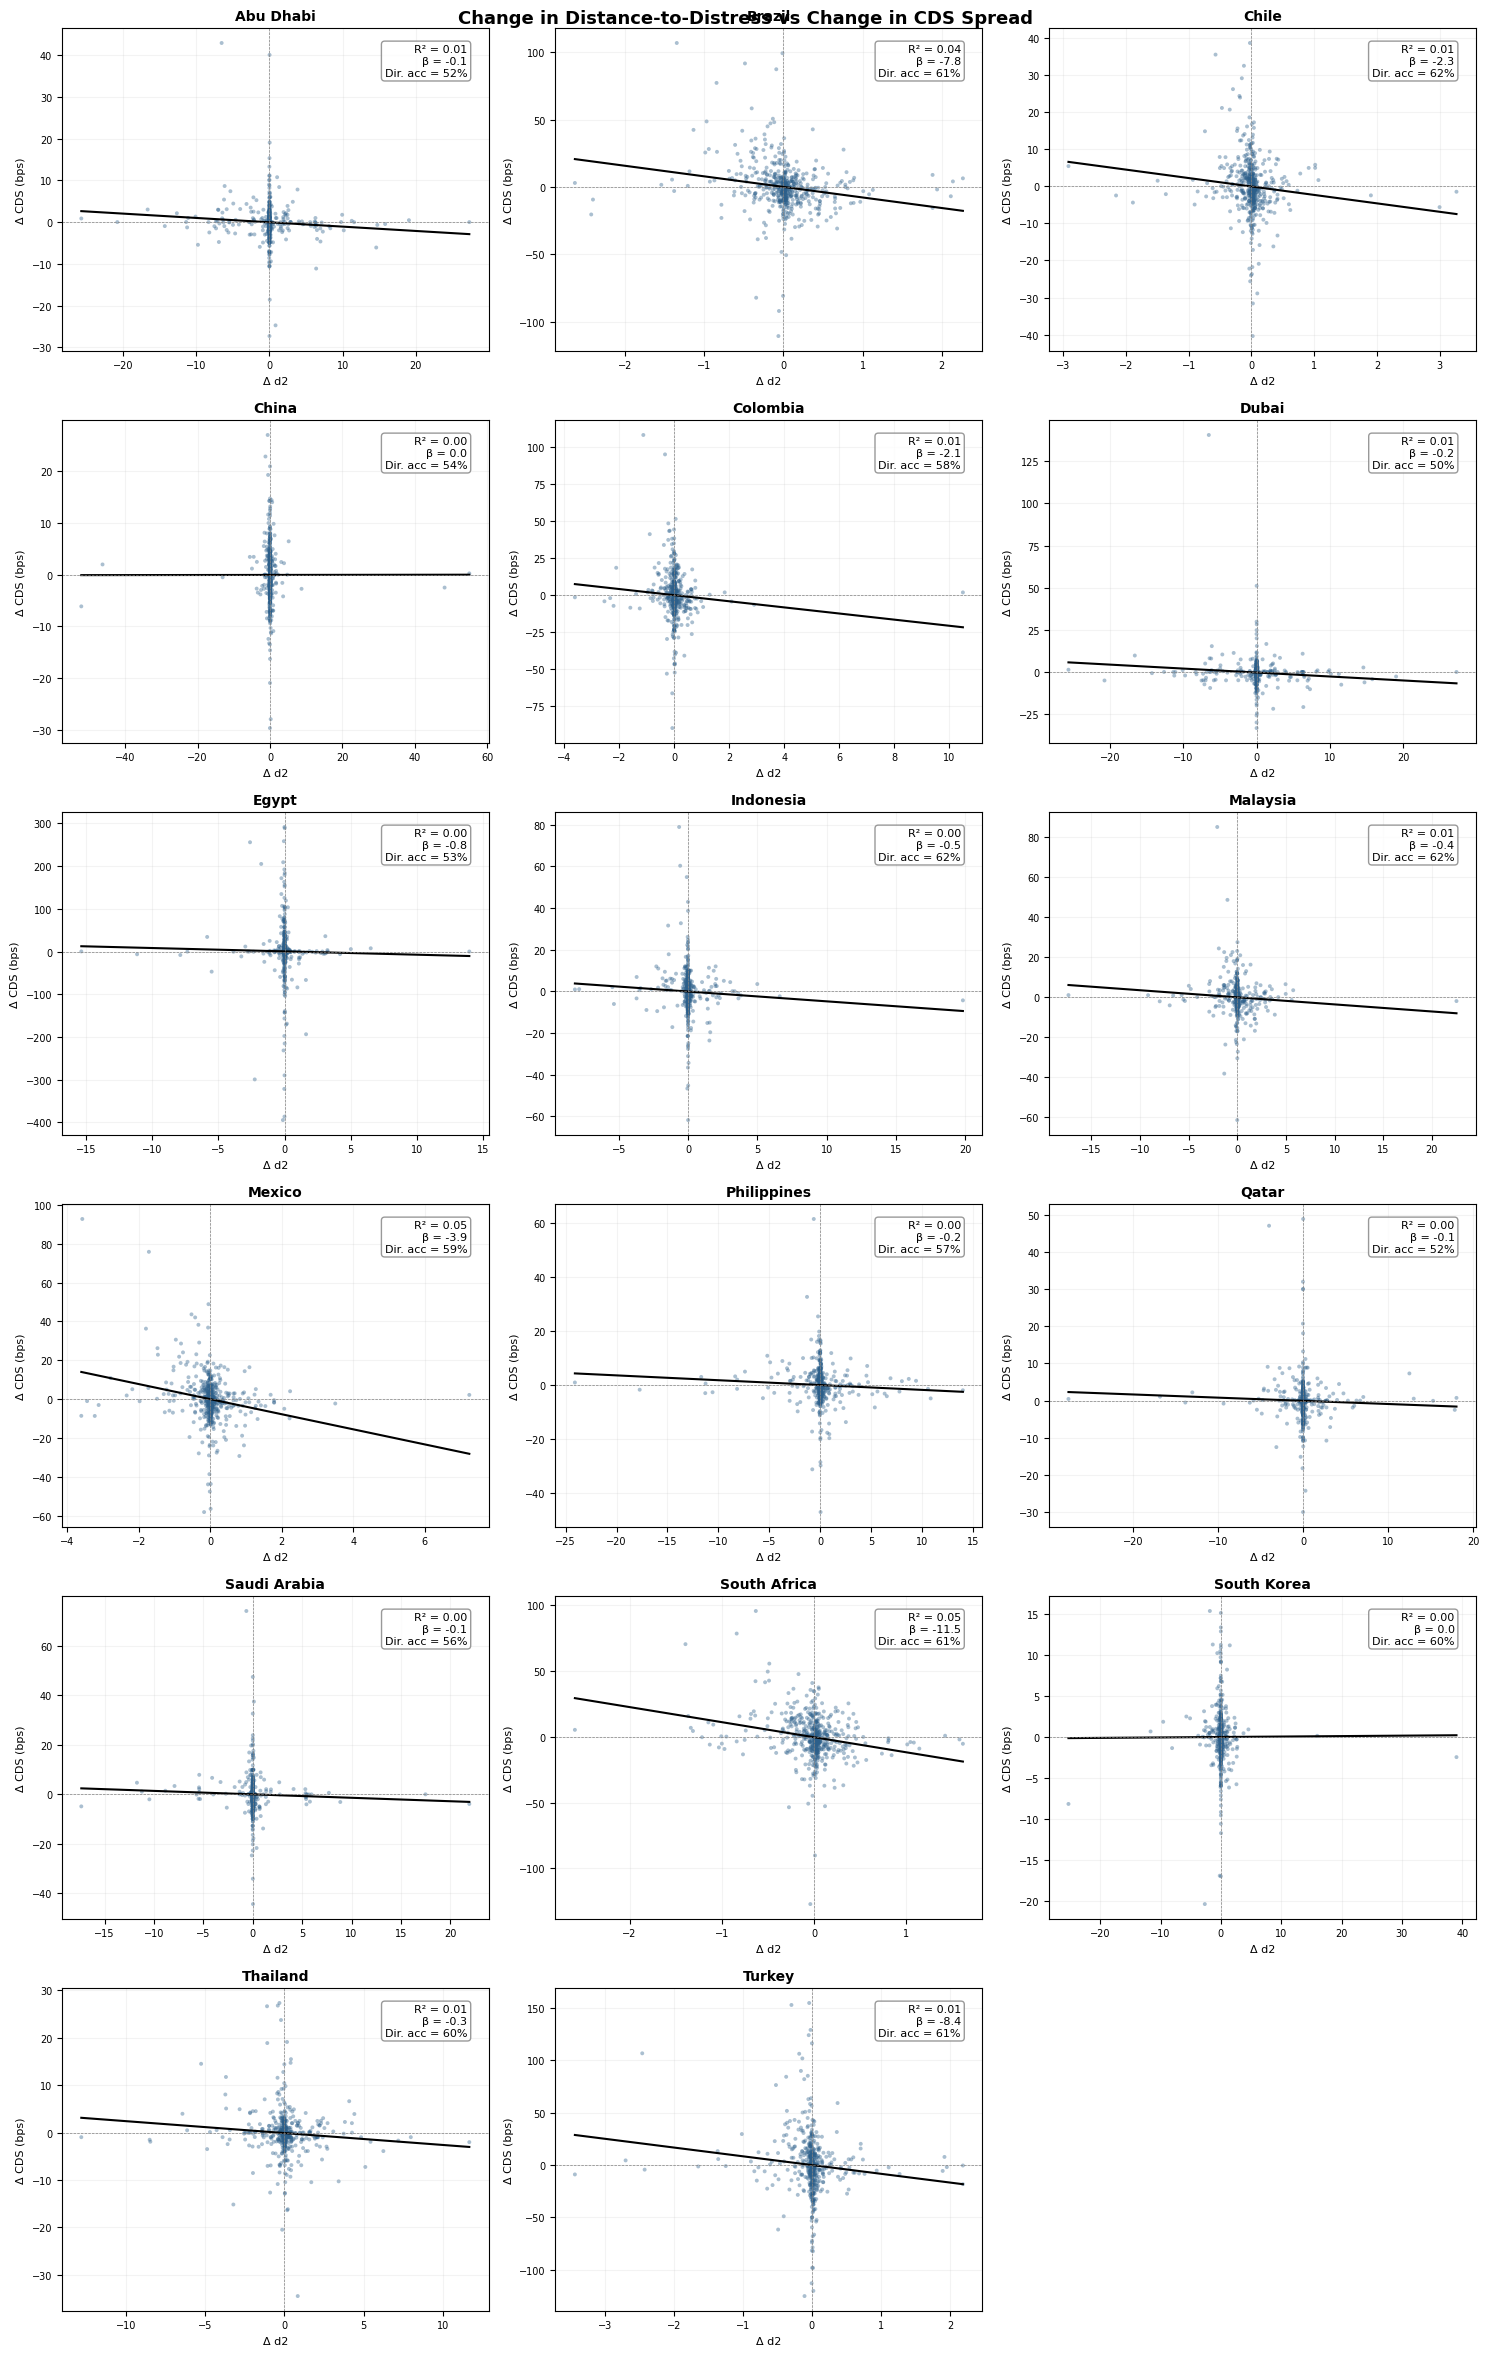

In [34]:
changes = plot_changes(results)

In [11]:
results

,country,date,year,quarter,month,week,cds_spread,fx_rate,msci_index,monetary_base_mn_localcurr,...,lamovx,implied_V,implied_sigma_V,cca_converged,distance_to_distress,default_prob,model_spread_bps,put_value,risky_debt,leverage
0,Abu Dhabi,2014-01-03,2014,1.0,1.0,1.0,7.12000,3.672000,749.581,288310.000,...,0,NaN,NaN,True,40.109649,0.000000e+00,1.713039e-13,0.000000e+00,22.889461,0.048010
1,Abu Dhabi,2014-01-10,2014,1.0,1.0,2.0,6.62000,3.672000,771.135,288310.000,...,0,NaN,NaN,True,40.109647,0.000000e+00,-4.401861e-13,0.000000e+00,22.889464,0.048005
2,Abu Dhabi,2014-01-17,2014,1.0,1.0,3.0,6.12000,3.672000,777.754,288310.000,...,0,NaN,NaN,True,40.109646,0.000000e+00,1.283695e-12,0.000000e+00,22.889466,0.048001
3,Abu Dhabi,2014-01-24,2014,1.0,1.0,4.0,6.12000,3.672000,808.655,288310.000,...,0,NaN,NaN,True,40.109646,0.000000e+00,1.283695e-12,0.000000e+00,22.889466,0.048001
4,Abu Dhabi,2014-01-31,2014,1.0,1.0,5.0,7.12000,3.672000,804.960,288310.000,...,0,NaN,NaN,True,40.109644,0.000000e+00,4.293441e-13,0.000000e+00,22.889469,0.047996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
569,Turkey,2024-11-29,2024,4.0,11.0,48.0,94.17000,34.656799,610.455,6067888.530,...,0,729.711611,0.243662,True,6.209222,2.662381e-10,9.704425e-08,1.523456e-09,156.986768,0.219767
570,Turkey,2024-12-06,2024,4.0,12.0,49.0,90.66000,34.737999,610.777,6585275.534,...,0,752.557156,0.246977,True,6.209040,2.665466e-10,9.715867e-08,1.525330e-09,156.993800,0.219536
571,Turkey,2024-12-13,2024,4.0,12.0,50.0,92.50000,34.943001,644.678,6585275.534,...,0,748.763999,0.246805,True,6.209122,2.664073e-10,9.710580e-08,1.524484e-09,156.990625,0.219641
572,Turkey,2024-12-20,2024,4.0,12.0,51.0,96.20000,35.069801,626.599,6585275.534,...,0,746.445561,0.246639,True,6.209172,2.663229e-10,9.707353e-08,1.523972e-09,156.988703,0.219704
